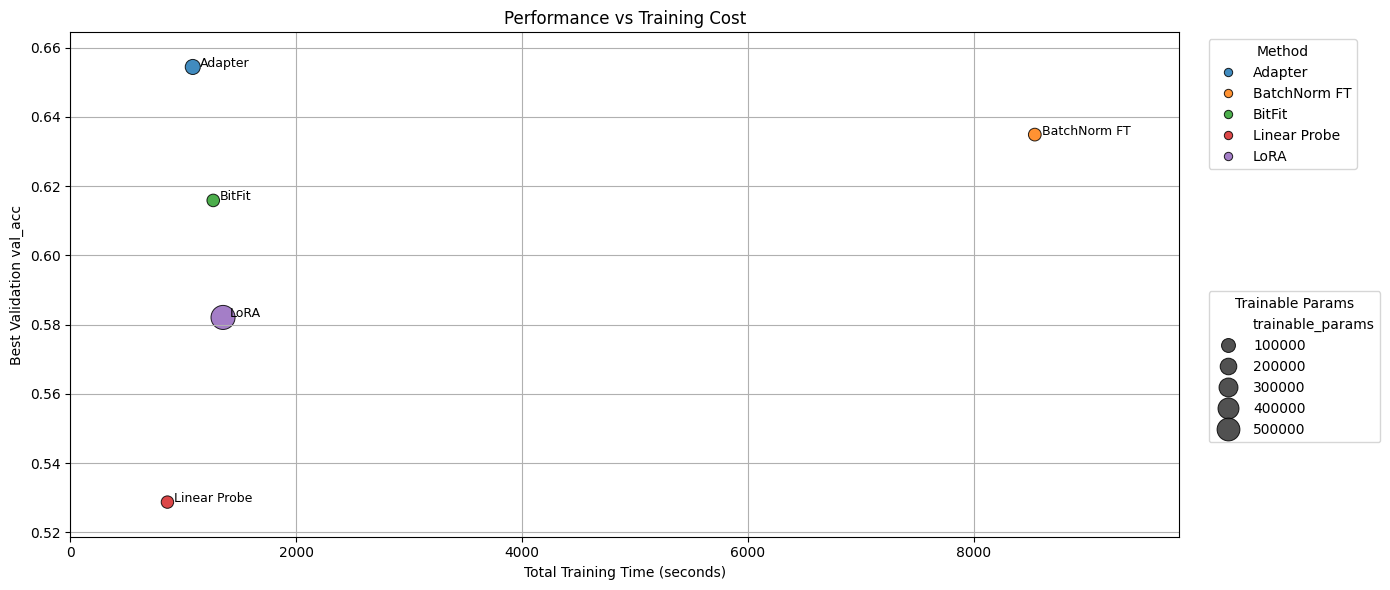

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\preet\Documents\UBC_MDS\DATA586\Project_final\training_scripts\ResNet18\results\ResNet18_metrics_with_additional_info.txt")

name_map = {
    "linear_probe": "Linear Probe",
    "batchnorm_finetune": "BatchNorm FT",
    "adapter_finetune": "Adapter",
    "resnet_real_Lora": "LoRA",
    "resnet18_bitfit": "BitFit"
}

df["method_clean"] = df["method"].map(name_map)

agg_df = df.groupby("method_clean").agg({
    "val_acc": "max",
    "epoch_time_sec": "sum",
    "trainable_params": "first"
}).reset_index()

agg_df = agg_df.rename(columns={
    "val_acc": "best_val_acc",
    "epoch_time_sec": "total_train_time"
})

# =========================
# Plot
# =========================
plt.figure(figsize=(14, 6))

scatter = sns.scatterplot(
    data=agg_df,
    x="total_train_time",
    y="best_val_acc",
    hue="method_clean",
    size="trainable_params",
    sizes=(80, 300), 
    alpha=0.85,
    edgecolor="black",
    legend="brief"
)

# =========================
# Legend fix
# =========================
handles, labels = scatter.get_legend_handles_labels()

n_methods = len(agg_df)

legend1 = plt.legend(
    handles[1:n_methods+1],
    labels[1:n_methods+1],
    title="Method",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

legend2 = plt.legend(
    handles[n_methods+1:],
    labels[n_methods+1:],
    title="Trainable Params", 
    bbox_to_anchor=(1.02, 0.5),
    loc="upper left"
)

plt.gca().add_artist(legend1)

# =========================
# Labels
# =========================
for _, row in agg_df.iterrows():
    plt.annotate(
        row["method_clean"],
        (row["total_train_time"], row["best_val_acc"]),
        textcoords="offset points",
        xytext=(5, 0),   # small right shift
        fontsize=9
    )

plt.xlabel("Total Training Time (seconds)")
plt.ylabel("Best Validation val_acc")
plt.title("Performance vs Training Cost")

plt.grid(True)
plt.tight_layout()
plt.xlim(0, agg_df["total_train_time"].max() * 1.15)
plt.ylim(agg_df["best_val_acc"].min() - 0.01,
         agg_df["best_val_acc"].max() + 0.01)
plt.show()

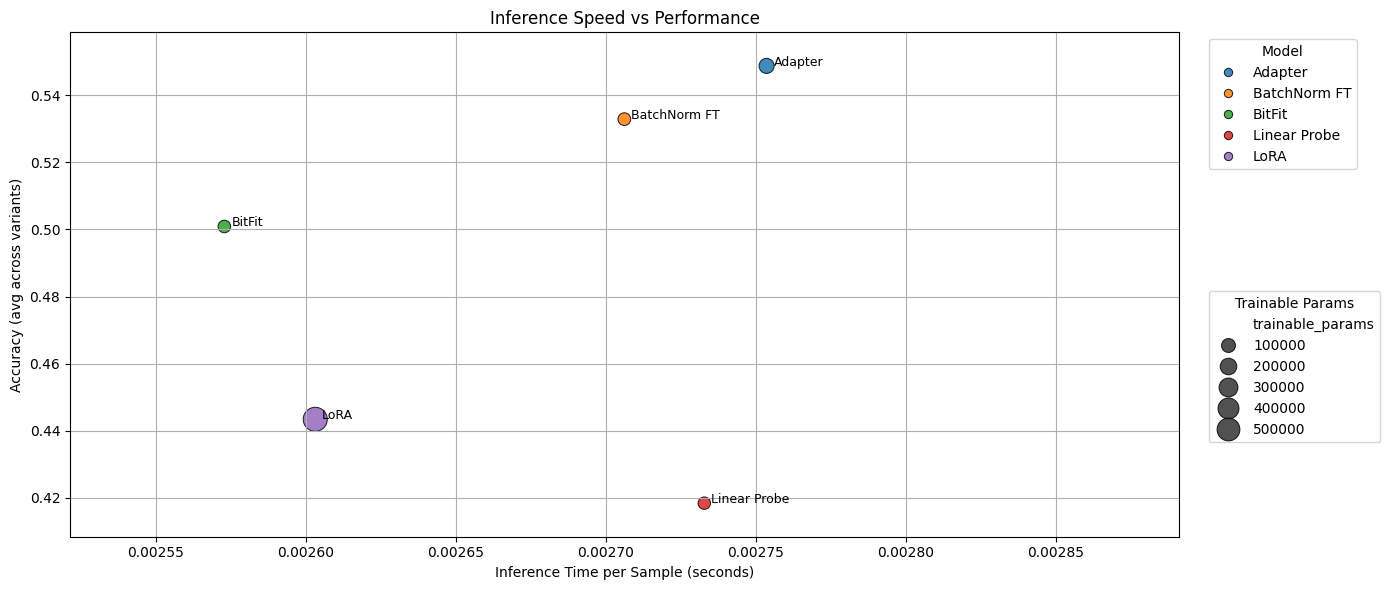

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. Load test results
# =========================
df = pd.read_csv(r"C:\Users\preet\Documents\UBC_MDS\DATA586\Project_final\test_scripts\variant\results_variants_resnet.csv")

# =========================
# 2. Clean model names
# =========================
name_map = {
    "linear_probe": "Linear Probe",
    "batchnorm": "BatchNorm FT",
    "adapter": "Adapter",
    "lora": "LoRA",
    "bitfit": "BitFit"
}

df["model_clean"] = df["model"].map(name_map)

# =========================
# 3. (Optional) Average across variants
# =========================
# This gives ONE point per model (cleaner plot)

agg_df = df.groupby("model_clean").agg({
    "accuracy": "mean",
    "time_per_sample_sec": "mean"
}).reset_index()

# =========================
# 4. Add trainable params (from training)
# =========================
# Manually define (from your training logs)

param_map = {
    "Linear Probe": 51813,
    "BatchNorm FT": 61413,
    "Adapter": 140893,
    "LoRA": 572517,
    "BitFit": 56613
}

agg_df["trainable_params"] = agg_df["model_clean"].map(param_map)

# =========================
# 5. Plot
# =========================
plt.figure(figsize=(14, 6))

scatter = sns.scatterplot(
    data=agg_df,
    x="time_per_sample_sec",
    y="accuracy",
    hue="model_clean",
    size="trainable_params",
    sizes=(80, 300),
    alpha=0.85,
    edgecolor="black",
    legend="brief"
)

# =========================
# 6. Legend fix (same style)
# =========================
handles, labels = scatter.get_legend_handles_labels()
n_models = agg_df["model_clean"].nunique()

legend1 = plt.legend(
    handles[1:n_models+1],
    labels[1:n_models+1],
    title="Model",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

legend2 = plt.legend(
    handles[n_models+1:],
    labels[n_models+1:],
    title="Trainable Params",
    bbox_to_anchor=(1.02, 0.5),
    loc="upper left"
)

plt.gca().add_artist(legend1)

# =========================
# 7. Labels
# =========================
for _, row in agg_df.iterrows():
    plt.annotate(
        row["model_clean"],
        (row["time_per_sample_sec"], row["accuracy"]),
        textcoords="offset points",
        xytext=(5, 0),
        fontsize=9
    )

plt.xlabel("Inference Time per Sample (seconds)")
plt.ylabel("Accuracy (avg across variants)")
plt.title("Inference Speed vs Performance")

plt.grid(True)
plt.tight_layout()

plt.xlim(agg_df["time_per_sample_sec"].min() * 0.98,
         agg_df["time_per_sample_sec"].max() * 1.05)

plt.ylim(agg_df["accuracy"].min() - 0.01,
         agg_df["accuracy"].max() + 0.01)

plt.show()

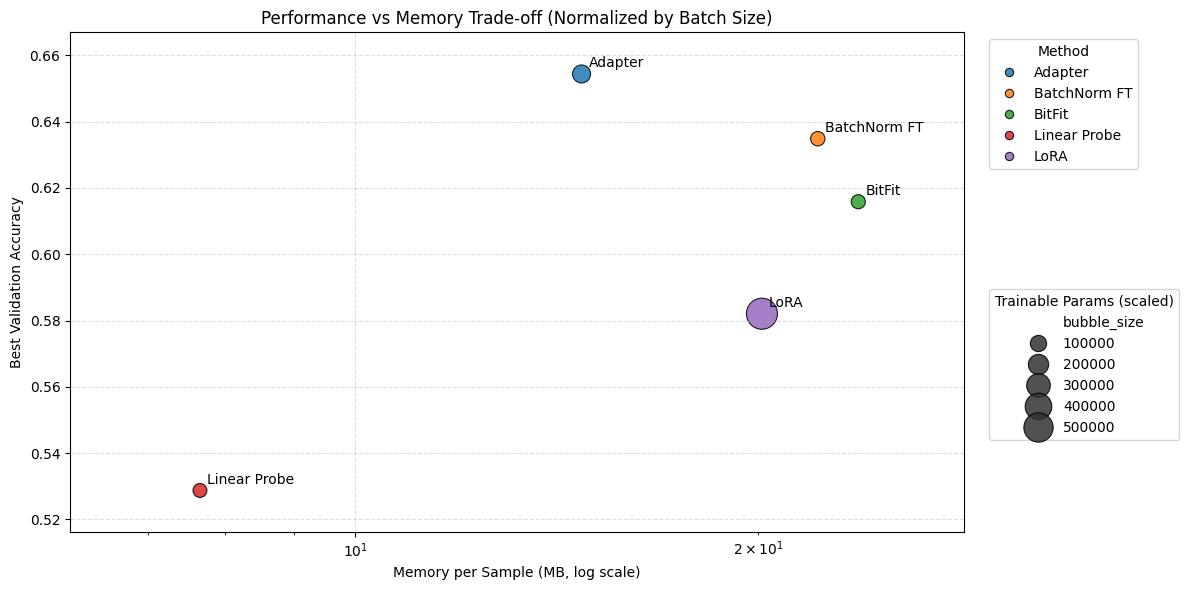

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. Load training data
# =========================
df = pd.read_csv(
    r"C:\Users\preet\Documents\UBC_MDS\DATA586\Project_final\training_scripts\ResNet18\results\ResNet18_metrics_with_additional_info.txt"
)

# =========================
# 2. Clean method names
# =========================
name_map = {
    "linear_probe": "Linear Probe",
    "batchnorm_finetune": "BatchNorm FT",
    "adapter_finetune": "Adapter",
    "resnet_real_Lora": "LoRA",
    "resnet18_bitfit": "BitFit"
}

df["method_clean"] = df["method"].map(name_map)

# =========================
# 3. FIX: Normalize memory by batch size
# =========================
df["memory_per_sample"] = df["peak_memory_mb"] / df["batch_size"]

# =========================
# 4. Aggregate per method
# =========================
agg_df = df.groupby("method_clean").agg({
    "val_acc": "max",                 # best validation accuracy
    "memory_per_sample": "mean",      # normalized memory
    "trainable_params": "first"
}).reset_index()

agg_df = agg_df.rename(columns={
    "val_acc": "best_val_acc",
    "memory_per_sample": "mem_per_sample"
})

# =========================
# 5. Bubble size scaling (IMPORTANT)
# =========================
agg_df["bubble_size"] = agg_df["trainable_params"]

# =========================
# 6. Plot
# =========================
plt.figure(figsize=(12, 6))

scatter = sns.scatterplot(
    data=agg_df,
    x="mem_per_sample",
    y="best_val_acc",
    hue="method_clean",
    size="bubble_size",
    sizes=(100, 500),
    alpha=0.85,
    edgecolor="black",
    legend="brief"
)

# =========================
# 7. OPTIONAL: log scale (highly recommended)
# =========================
plt.xscale("log")

# =========================
# 8. Legend cleanup
# =========================
handles, labels = scatter.get_legend_handles_labels()
n_methods = agg_df["method_clean"].nunique()

legend1 = plt.legend(
    handles[1:n_methods+1],
    labels[1:n_methods+1],
    title="Method",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

legend2 = plt.legend(
    handles[n_methods+1:],
    labels[n_methods+1:],
    title="Trainable Params (scaled)",
    bbox_to_anchor=(1.02, 0.5),
    loc="upper left"
)

plt.gca().add_artist(legend1)

# =========================
# 9. Annotate points
# =========================
for _, row in agg_df.iterrows():
    plt.annotate(
        row["method_clean"],
        (row["mem_per_sample"], row["best_val_acc"]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=10
    )

# =========================
# 10. Labels + styling
# =========================
plt.xlabel("Memory per Sample (MB, log scale)")
plt.ylabel("Best Validation Accuracy")
plt.title("Performance vs Memory Trade-off (Normalized by Batch Size)")

plt.grid(True, linestyle="--", alpha=0.4)

# =========================
# 11. Smart axis padding
# =========================
x_min, x_max = agg_df["mem_per_sample"].min(), agg_df["mem_per_sample"].max()
y_min, y_max = agg_df["best_val_acc"].min(), agg_df["best_val_acc"].max()

x_pad = (x_max - x_min) * 0.2
y_pad = (y_max - y_min) * 0.1

plt.xlim(x_min * 0.8, x_max * 1.2)
plt.ylim(y_min - y_pad, y_max + y_pad)

plt.tight_layout()
plt.show()

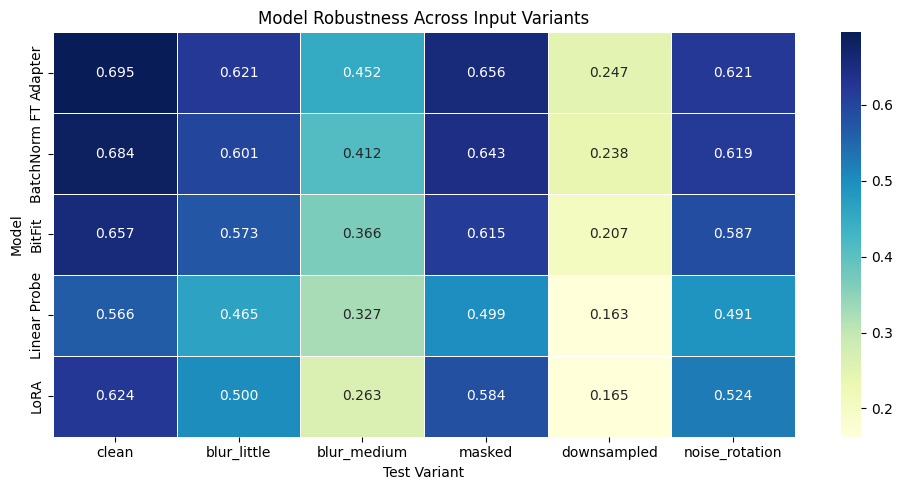

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. Load test results
# =========================
df = pd.read_csv(r"C:\Users\preet\Documents\UBC_MDS\DATA586\Project_final\test_scripts\variant\results_variants_resnet.csv")

# =========================
# 2. Clean model names
# =========================
name_map = {
    "linear_probe": "Linear Probe",
    "batchnorm": "BatchNorm FT",
    "adapter": "Adapter",
    "lora": "LoRA",
    "bitfit": "BitFit"
}

df["model_clean"] = df["model"].map(name_map)

# =========================
# 3. Pivot into matrix form
# =========================
heatmap_data = df.pivot_table(
    index="model_clean",
    columns="variant",
    values="accuracy",
    aggfunc="mean"
)

# Optional: order columns nicely (if needed)
preferred_order = [
    "clean",
    "blur_little",
    "blur_medium",
    "masked",
    "downsampled",
    "noise_rotation"
]

heatmap_data = heatmap_data.reindex(columns=preferred_order)

# =========================
# 4. Plot heatmap
# =========================
plt.figure(figsize=(10, 5))

sns.heatmap(
    heatmap_data,
    annot=True,           # show values
    fmt=".3f",
    cmap="YlGnBu",        # good academic colormap
    linewidths=0.5,
    linecolor="white"
)

plt.title("Model Robustness Across Input Variants")
plt.xlabel("Test Variant")
plt.ylabel("Model")

plt.tight_layout()
plt.show()

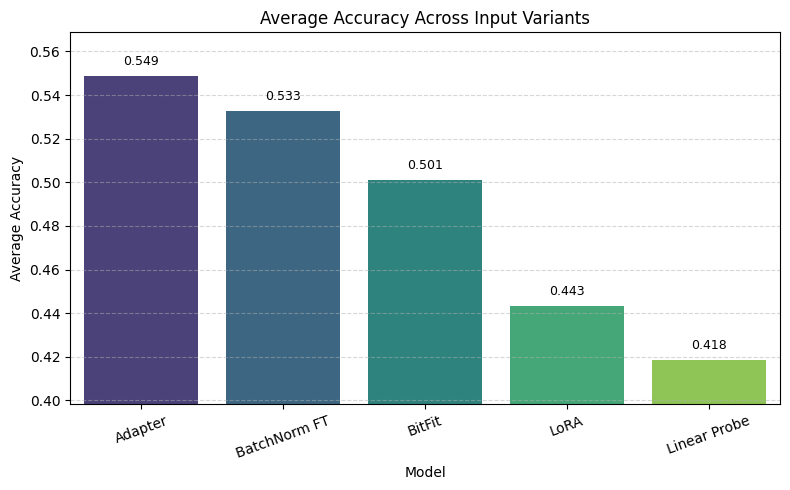

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. Load test results
# =========================
df = pd.read_csv(r"C:\Users\preet\Documents\UBC_MDS\DATA586\Project_final\test_scripts\variant\results_variants_resnet.csv")

# =========================
# 2. Clean model names
# =========================
name_map = {
    "linear_probe": "Linear Probe",
    "batchnorm": "BatchNorm FT",
    "adapter": "Adapter",
    "lora": "LoRA",
    "bitfit": "BitFit"
}

df["model_clean"] = df["model"].map(name_map)

# =========================
# 3. Average accuracy per model
# =========================
agg_df = df.groupby("model_clean")["accuracy"].mean().reset_index()
agg_df = agg_df.sort_values("accuracy", ascending=False)

# =========================
# 4. Plot
# =========================
plt.figure(figsize=(8, 5))

sns.barplot(
    data=agg_df,
    x="model_clean",
    y="accuracy",
    hue="model_clean",
    palette="viridis",
    legend=False
)

# =========================
# 5. Labels & formatting
# =========================
plt.title("Average Accuracy Across Input Variants")
plt.xlabel("Model")
plt.ylabel("Average Accuracy")

plt.ylim(agg_df["accuracy"].min() - 0.02,
         agg_df["accuracy"].max() + 0.02)

plt.grid(axis="y", linestyle="--", alpha=0.5)

# rotate labels if needed
plt.xticks(rotation=20)

# annotate values on bars
for i, (idx, row) in enumerate(agg_df.iterrows()):
    plt.text(
        i,
        row["accuracy"] + 0.005,
        f"{row['accuracy']:.3f}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

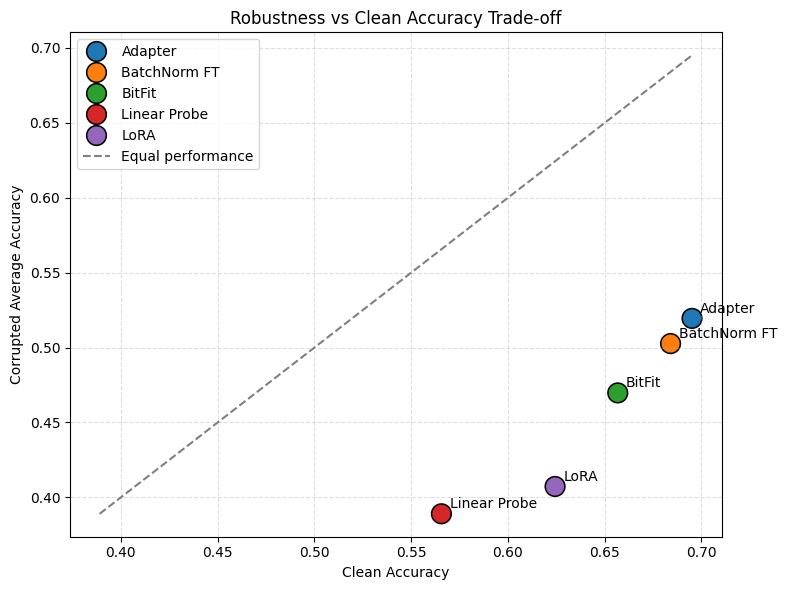

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. Load test results
# =========================
df = pd.read_csv(r"C:\Users\preet\Documents\UBC_MDS\DATA586\Project_final\test_scripts\variant\results_variants_resnet.csv")

# =========================
# 2. Clean model names
# =========================
name_map = {
    "linear_probe": "Linear Probe",
    "batchnorm": "BatchNorm FT",
    "adapter": "Adapter",
    "lora": "LoRA",
    "bitfit": "BitFit"
}

df["model_clean"] = df["model"].map(name_map)

# =========================
# 3. Separate clean vs corrupted
# =========================
# adjust these if your dataset uses different naming
clean_df = df[df["variant"] == "clean"]
corr_df = df[df["variant"] != "clean"]

# =========================
# 4. Aggregate metrics
# =========================
clean_acc = clean_df.groupby("model_clean")["accuracy"].mean()
corr_acc = corr_df.groupby("model_clean")["accuracy"].mean()

agg_df = pd.DataFrame({
    "clean_acc": clean_acc,
    "corrupt_acc": corr_acc
}).reset_index()

# =========================
# 5. Plot
# =========================
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=agg_df,
    x="clean_acc",
    y="corrupt_acc",
    hue="model_clean",
    s=200,
    edgecolor="black"
)

# =========================
# 6. Annotate points
# =========================
for _, row in agg_df.iterrows():
    plt.annotate(
        row["model_clean"],
        (row["clean_acc"], row["corrupt_acc"]),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=10
    )

# =========================
# 7. Reference line (important!)
# =========================
min_val = min(agg_df["clean_acc"].min(), agg_df["corrupt_acc"].min())
max_val = max(agg_df["clean_acc"].max(), agg_df["corrupt_acc"].max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    color="gray",
    label="Equal performance"
)

# =========================
# 8. Labels
# =========================
plt.xlabel("Clean Accuracy")
plt.ylabel("Corrupted Average Accuracy")
plt.title("Robustness vs Clean Accuracy Trade-off")

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

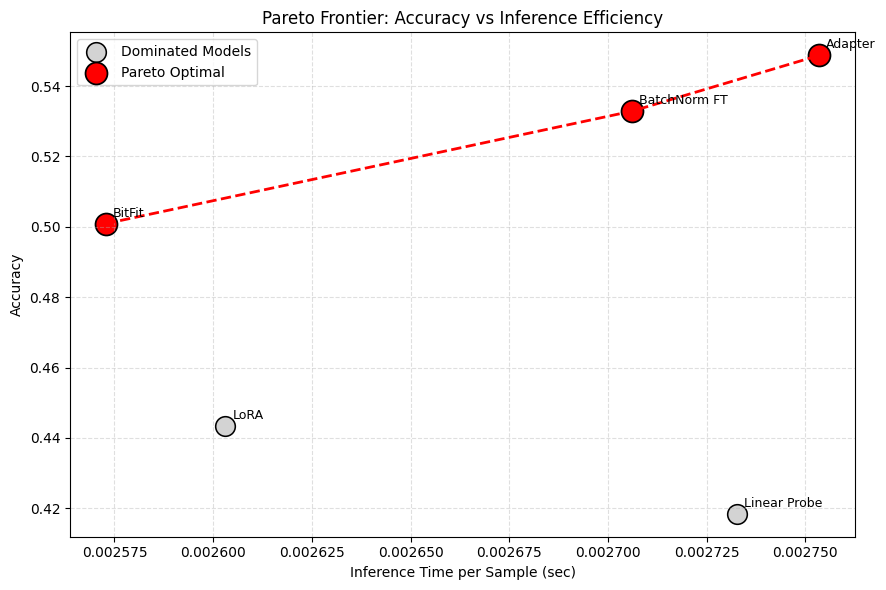

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# =========================
# 1. Load test results
# =========================
df = pd.read_csv(r"C:\Users\preet\Documents\UBC_MDS\DATA586\Project_final\test_scripts\variant\results_variants_resnet.csv")

# =========================
# 2. Clean model names
# =========================
name_map = {
    "linear_probe": "Linear Probe",
    "batchnorm": "BatchNorm FT",
    "adapter": "Adapter",
    "lora": "LoRA",
    "bitfit": "BitFit"
}

df["model_clean"] = df["model"].map(name_map)

# =========================
# 3. Aggregate per model
# =========================
agg_df = df.groupby("model_clean").agg({
    "accuracy": "mean",
    "time_per_sample_sec": "mean"
}).reset_index()

agg_df = agg_df.sort_values("time_per_sample_sec")

# =========================
# 4. Compute Pareto frontier
# =========================
# A model is Pareto optimal if no other model
# has BOTH higher accuracy AND lower/equal inference time

pareto_points = []

for i, row in agg_df.iterrows():
    dominated = False
    for j, other in agg_df.iterrows():
        if (other["accuracy"] >= row["accuracy"]) and (other["time_per_sample_sec"] <= row["time_per_sample_sec"]):
            if (other["accuracy"] > row["accuracy"]) or (other["time_per_sample_sec"] < row["time_per_sample_sec"]):
                dominated = True
                break
    if not dominated:
        pareto_points.append(row)

pareto_df = pd.DataFrame(pareto_points)

# =========================
# 5. Plot all models
# =========================
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=agg_df,
    x="time_per_sample_sec",
    y="accuracy",
    s=200,
    color="lightgray",
    edgecolor="black",
    label="Dominated Models"
)

# =========================
# 6. Plot Pareto frontier
# =========================
sns.scatterplot(
    data=pareto_df,
    x="time_per_sample_sec",
    y="accuracy",
    s=250,
    color="red",
    edgecolor="black",
    label="Pareto Optimal"
)

# connect frontier points
pareto_df = pareto_df.sort_values("time_per_sample_sec")

plt.plot(
    pareto_df["time_per_sample_sec"],
    pareto_df["accuracy"],
    color="red",
    linestyle="--",
    linewidth=2
)

# =========================
# 7. Annotate points
# =========================
for _, row in agg_df.iterrows():
    plt.annotate(
        row["model_clean"],
        (row["time_per_sample_sec"], row["accuracy"]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=9
    )

# =========================
# 8. Labels
# =========================
plt.xlabel("Inference Time per Sample (sec)")
plt.ylabel("Accuracy")
plt.title("Pareto Frontier: Accuracy vs Inference Efficiency")

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()

plt.show()

C:\Users\preet\AppData\Local\Temp\ipykernel_43808\3342226983.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg_df = df.groupby(["model_clean", "variant"])["accuracy"].mean().reset_index()


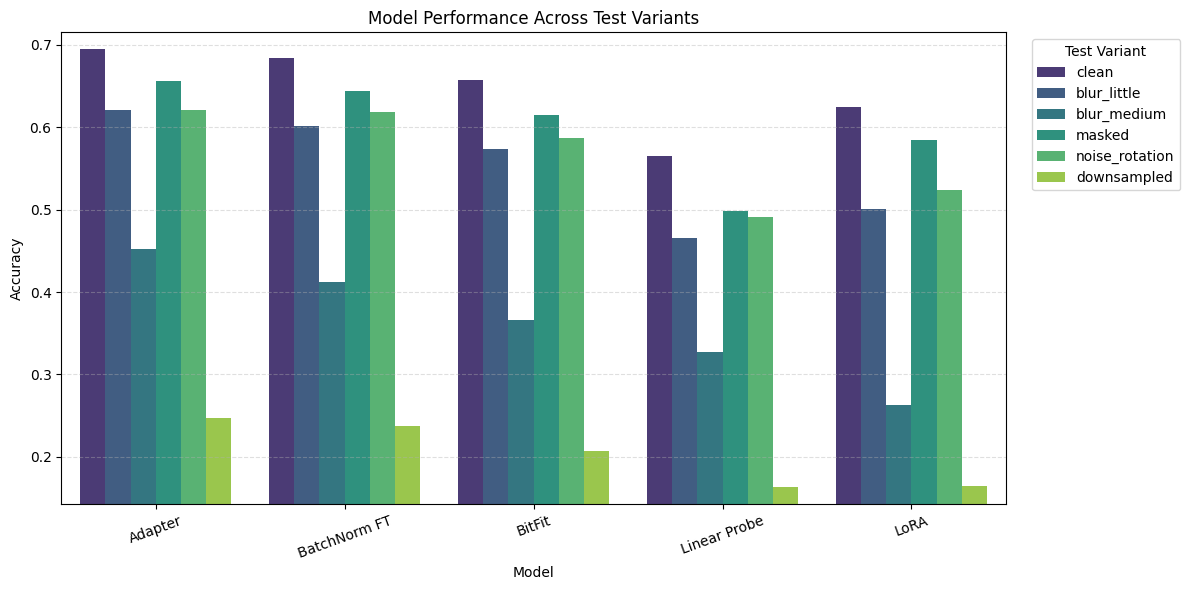

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. Load test results
# =========================
df = pd.read_csv(r"C:\Users\preet\Documents\UBC_MDS\DATA586\Project_final\test_scripts\variant\results_variants_resnet.csv")

# =========================
# 2. Clean model names
# =========================
name_map = {
    "linear_probe": "Linear Probe",
    "batchnorm": "BatchNorm FT",
    "adapter": "Adapter",
    "lora": "LoRA",
    "bitfit": "BitFit"
}

df["model_clean"] = df["model"].map(name_map)

# =========================
# 3. OPTIONAL: ensure nice ordering of variants
# =========================
variant_order = ["clean", "blur_little", "blur_medium", "masked", "noise_rotation","downsampled"]

df["variant"] = pd.Categorical(df["variant"], categories=variant_order, ordered=True)

# =========================
# 4. Aggregate (mean accuracy per group)
# =========================
agg_df = df.groupby(["model_clean", "variant"])["accuracy"].mean().reset_index()

# =========================
# 5. Plot
# =========================
plt.figure(figsize=(12, 6))

sns.barplot(
    data=agg_df,
    x="model_clean",
    y="accuracy",
    hue="variant",
    palette="viridis"
)

# =========================
# 6. Labels & formatting
# =========================
plt.title("Model Performance Across Test Variants")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.ylim(agg_df["accuracy"].min() - 0.02,
         agg_df["accuracy"].max() + 0.02)

plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.legend(title="Test Variant", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

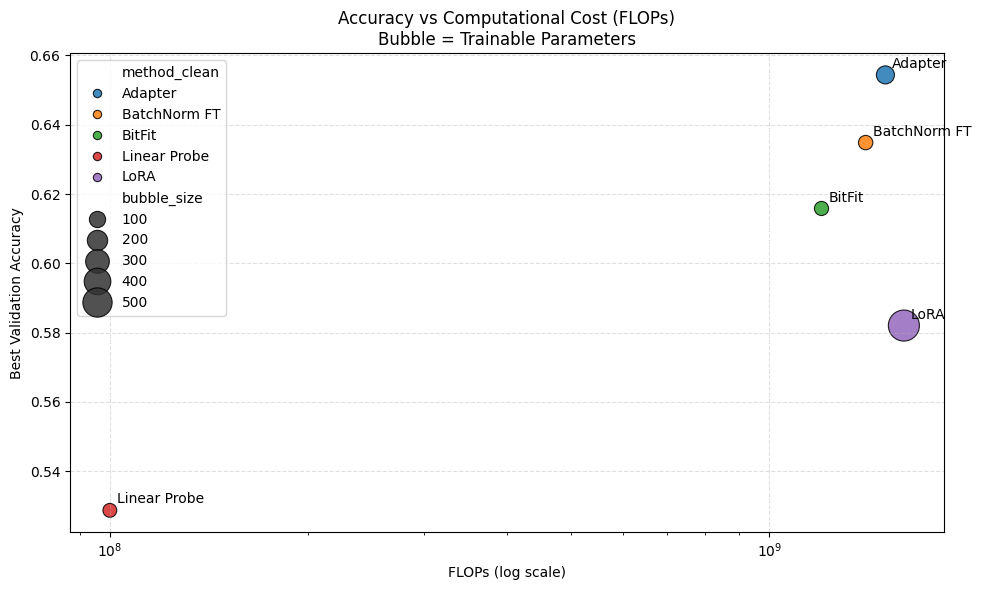

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. Load test results
# =========================
df = pd.read_csv(r"C:\Users\preet\Documents\UBC_MDS\DATA586\Project_final\training_scripts\ResNet18\results\ResNet18_metrics_with_additional_info.txt")

# =========================
# 2. Clean method names
# =========================
name_map = {
    "linear_probe": "Linear Probe",
    "batchnorm_finetune": "BatchNorm FT",
    "adapter_finetune": "Adapter",
    "resnet_real_Lora": "LoRA",
    "resnet18_bitfit": "BitFit"
}

df["method_clean"] = df["method"].map(name_map)

# =========================
# 3. Aggregate accuracy + params
# =========================
agg_df = df.groupby("method_clean").agg({
    "val_acc": "max",
    "trainable_params": "first"
}).reset_index()

agg_df = agg_df.rename(columns={
    "val_acc": "best_val_acc"
})

# =========================
# 4. FLOPs (YOU MUST PROVIDE / ESTIMATE)
# =========================
# Replace these with your real computed FLOPs if available
flop_map = {
    "Linear Probe": 1e8,
    "BitFit": 1.2e9,
    "Adapter": 1.5e9,
    "LoRA": 1.6e9,
    "BatchNorm FT": 1.4e9
}

agg_df["flops"] = agg_df["method_clean"].map(flop_map)

# =========================
# 5. Bubble scaling
# =========================
agg_df["bubble_size"] = agg_df["trainable_params"] / 1000

# =========================
# 6. Plot
# =========================
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=agg_df,
    x="flops",
    y="best_val_acc",
    hue="method_clean",
    size="bubble_size",
    sizes=(100, 500),
    alpha=0.85,
    edgecolor="black",
    legend="brief"
)

# =========================
# 7. Log scale (VERY IMPORTANT)
# =========================
plt.xscale("log")

# =========================
# 8. Annotations
# =========================
for _, row in agg_df.iterrows():
    plt.annotate(
        row["method_clean"],
        (row["flops"], row["best_val_acc"]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=10
    )

# =========================
# 9. Labels
# =========================
plt.xlabel("FLOPs (log scale)")
plt.ylabel("Best Validation Accuracy")
plt.title("Accuracy vs Computational Cost (FLOPs)\nBubble = Trainable Parameters")

plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

plt.show()